In [175]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

In [176]:
# Ensure the project root is in the Python path for module imports
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from cd_poly.cd_poly import *

In [209]:
IMAGE_SIZE = 28 * 28  # MNIST image dimensions
LATENT_DIM = 64      # Dimension of the latent space
BATCH_SIZE = 256
LEARNING_RATE = 4e-3
NUM_EPOCHS = 20
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")

In [210]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

indices_3s_7s = []
for i, (image, label) in enumerate(full_mnist_train_dataset):
    if label == 3 or label == 7:
        indices_3s_7s.append(i)

train_ds = full_mnist_train_dataset
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [211]:
class AutoencoderCNN(nn.Module):
    def __init__(self, input_channels=1, latent_dim=64):
        super(AutoencoderCNN, self).__init__()

        # Encoder
        # Input: [batch_size, 1, 28, 28]
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 2, kernel_size=3, stride=2, padding=1), # Output: [batch_size, 2, 14, 14]
            nn.ReLU(),
            nn.Conv2d(2, 4, kernel_size=3, stride=2, padding=1),  # Output: [batch_size, 4, 7, 7]
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1), # Output: [batch_size, 8, 4, 4] (approx)
            nn.ReLU(),
            nn.Flatten(), # Flatten for the latent space
            nn.Linear(8 * 4 * 4, latent_dim) # Adjust this if output of last conv changes
        )

        # Decoder
        # Input: [batch_size, latent_dim]
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8 * 4 * 4), # Reshape back to convolutional dimensions
            nn.ReLU(),
            nn.Unflatten(1, (8, 4, 4)), # Unflatten to [batch_size, 8, 4, 4]
            nn.ConvTranspose2d(8, 4, kernel_size=3, stride=2, padding=1, output_padding=0), # Output: [batch_size, 4, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(4, 2, kernel_size=3, stride=2, padding=1, output_padding=1),  # Output: [batch_size, 2, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(2, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1), # Output: [batch_size, 1, 28, 28]
            nn.Sigmoid() # Sigmoid to output pixel values between 0 and 1
        )

    def forward(self, x):
        # Ensure input is reshaped for CNN: [batch_size, channels, height, width]
        # MNIST images are typically 28x28, 1 channel

        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec, enc

In [212]:
model = AutoencoderCNN(input_channels=1, latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss() # Mean Squared Error for reconstruction
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [213]:
# num of params
sum(p.numel() for p in model.parameters() if p.requires_grad)

17353

In [214]:
losses = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_dl):
        # Flatten the images and move to device
        data = data.to(DEVICE)

        # Forward pass
        rec, enc = model(data)
        loss = criterion(rec, data)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    losses.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.4f}")

print("Training finished.")

Epoch [5/20], Loss: 0.0364
Epoch [10/20], Loss: 0.0264
Epoch [15/20], Loss: 0.0230
Epoch [20/20], Loss: 0.0213
Training finished.


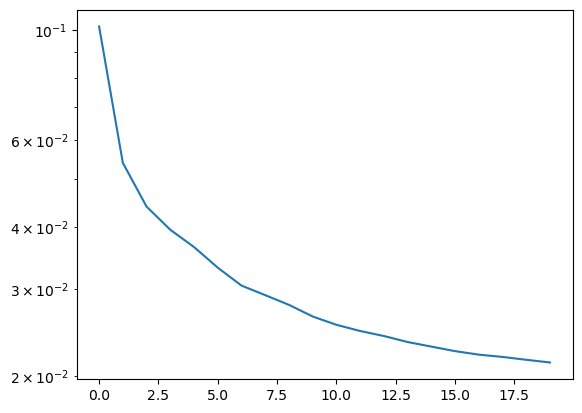

In [215]:
plt.plot(losses)
plt.yscale('log')

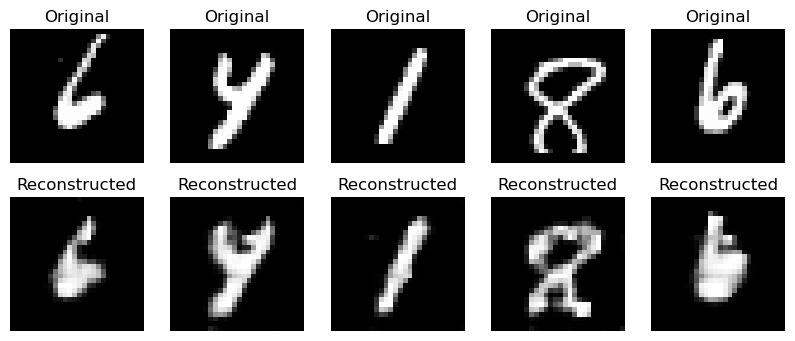

In [251]:
model.eval()
with torch.no_grad():
    sample_data, _ = next(iter(train_dl))
    sample_data = sample_data.to(DEVICE)
    rec, _ = model(sample_data)
    rec = rec.cpu()
    original_samples = sample_data.cpu()

    plt.figure(figsize=(10, 4))
    for i in range(5):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(original_samples[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        ax = plt.subplot(2, 5, i + 6)
        plt.imshow(rec[i].squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

In [249]:
import umap
u = umap.UMAP()

In [250]:
ds_5s = Subset(full_mnist_train_dataset, indices_5s)
dl_5s = DataLoader(ds_5s, batch_size=BATCH_SIZE)

ds_3s_7s = Subset(full_mnist_train_dataset, indices_3s_7s)
dl_3s_7s = DataLoader(ds_3s_7s, batch_size=BATCH_SIZE)

In [232]:
it = iter(dl_3s_7s)
latents = []
labels = []
for i in range(2):
    samples_x, samples_y = next(it)
    model.eval()
    with torch.no_grad():
        rec, enc = model(samples_x.to(DEVICE))
    latents.append(enc.to('cpu').numpy())
    labels.append(samples_y.to('cpu').numpy())
latents = np.concat(latents)
labels = np.concat(labels)

In [242]:
umap_latents = u.fit_transform(latents)

In [234]:
indices_5s = []
for i, (image, label) in enumerate(full_mnist_train_dataset):
    if label == 5:
        indices_5s.append(i)

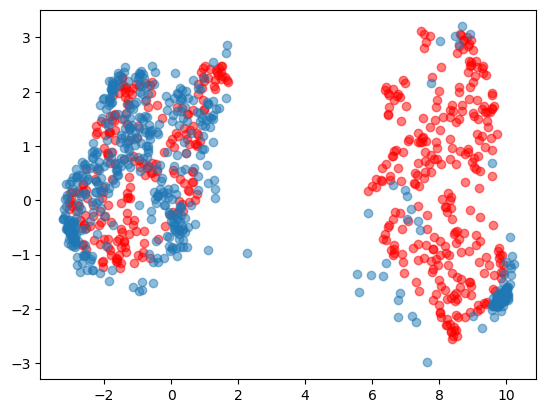

In [240]:
plt.scatter(*umap_latents.T, alpha=0.5, color='red')
plt.scatter(*umap_latents_5s.T, alpha=0.5)

In [243]:
umap_latents_5s = []

for i, (image, label) in enumerate(dl_5s):
    model.eval()
    with torch.no_grad():
        rec, enc = model(image.to(DEVICE))
    latents_5s = enc.to('cpu').numpy()
    umap_latents_5s.append(u.transform(latents_5s))
    if i == 1:
        break
umap_latents_5s = np.concatenate(umap_latents_5s)
umap_latents_5s.shape

(512, 2)

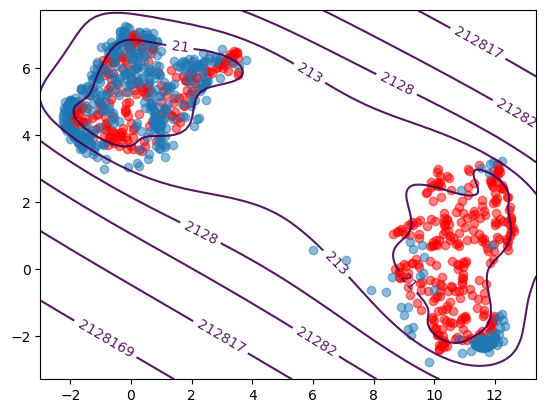

In [245]:
# plot latents, color by label
plt.scatter(*umap_latents.T, color='red', alpha=0.5)
plt.scatter(*umap_latents_5s.T, alpha=0.5)

p = CDPolynomial(umap_latents, degree=4)
p.plot(plt.gca(), multiplier=0.15)

Maybe the results would be better if the UMAP embedding were computed with all the latents together. But this is impractical and would negate one of the benefits of the CD polynomial (that it doesn't need to be recomputed for every test point)